# Skin Disease Detection - EfficientNet-B0 Training
### Stack: PyTorch + EfficientNet-B0 (Transfer Learning) | RTX 3060 Local

## Step 1: Install Dependencies

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install kagglehub scikit-learn matplotlib seaborn Pillow tqdm

Looking in indexes: https://download.pytorch.org/whl/cu121


## Step 2: Download Dataset from Kaggle

In [4]:
import kagglehub

path = kagglehub.dataset_download("ismailpromus/skin-diseases-image-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\ismailpromus\skin-diseases-image-dataset\versions\1


## Step 3: Explore Dataset Structure

In [5]:
import os

# Find the actual image folder inside the downloaded path
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # Only show files 2 levels deep
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:  # Show first 3 files per folder
            print(f'{subindent}{file}')

1/
  IMG_CLASSES/
    1. Eczema 1677/
    10. Warts Molluscum and other Viral Infections - 2103/
    2. Melanoma 15.75k/
    3. Atopic Dermatitis - 1.25k/
    4. Basal Cell Carcinoma (BCC) 3323/
    5. Melanocytic Nevi (NV) - 7970/
    6. Benign Keratosis-like Lesions (BKL) 2624/
    7. Psoriasis pictures Lichen Planus and related diseases - 2k/
    8. Seborrheic Keratoses and other Benign Tumors - 1.8k/
    9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k/


In [6]:
import os

# ---- SET THIS after running the cell above ----
# Look at the output above and find the folder that contains subfolders (disease classes)
# It will look something like: /root/.cache/kagglehub/.../train  OR  .../skin_diseases
# Set DATA_DIR to that folder

# Auto-detect: walk and find the folder with most subfolders (class folders)
best_dir = None
best_count = 0

for root, dirs, files in os.walk(path):
    if len(dirs) > best_count:
        best_count = len(dirs)
        best_dir = root

DATA_DIR = best_dir
print(f"Auto-detected DATA_DIR: {DATA_DIR}")
print(f"Number of classes found: {best_count}")
print(f"Classes: {os.listdir(DATA_DIR)[:10]}")

Auto-detected DATA_DIR: C:\Users\User\.cache\kagglehub\datasets\ismailpromus\skin-diseases-image-dataset\versions\1\IMG_CLASSES
Number of classes found: 10
Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


## Step 4: Imports & Config

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import json
import time

# ---- CONFIG ----
IMG_SIZE    = 224
BATCH_SIZE  = 32       # Good for RTX 3060 (12GB VRAM)
EPOCHS      = 15
LR          = 1e-4
NUM_WORKERS = 4
VAL_SPLIT   = 0.2
MODEL_SAVE  = "../model/efficientnet_skin.pth"
LABELS_SAVE = "../model/class_labels.json"

# Create model directory
os.makedirs("../model", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.9 GB


## Step 5: Data Transforms & Loaders

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   # ImageNet stats
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load full dataset first (no transform yet, we'll split then assign)
full_dataset = datasets.ImageFolder(root=DATA_DIR)

NUM_CLASSES = len(full_dataset.classes)
CLASS_NAMES = full_dataset.classes

print(f"Total images : {len(full_dataset)}")
print(f"Num classes  : {NUM_CLASSES}")
print(f"Class names  : {CLASS_NAMES}")

# Save class labels for inference later
with open(LABELS_SAVE, 'w') as f:
    json.dump(CLASS_NAMES, f)
print(f"Class labels saved to {LABELS_SAVE}")

Total images : 27153
Num classes  : 10
Class names  : ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']
Class labels saved to ../model/class_labels.json


In [9]:
# Train/Val split
val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Assign transforms
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform   = val_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train samples: {train_size} | Val samples: {val_size}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train samples: 21723 | Val samples: 5430
Train batches: 679 | Val batches: 170


## Step 6: Visualize Sample Images

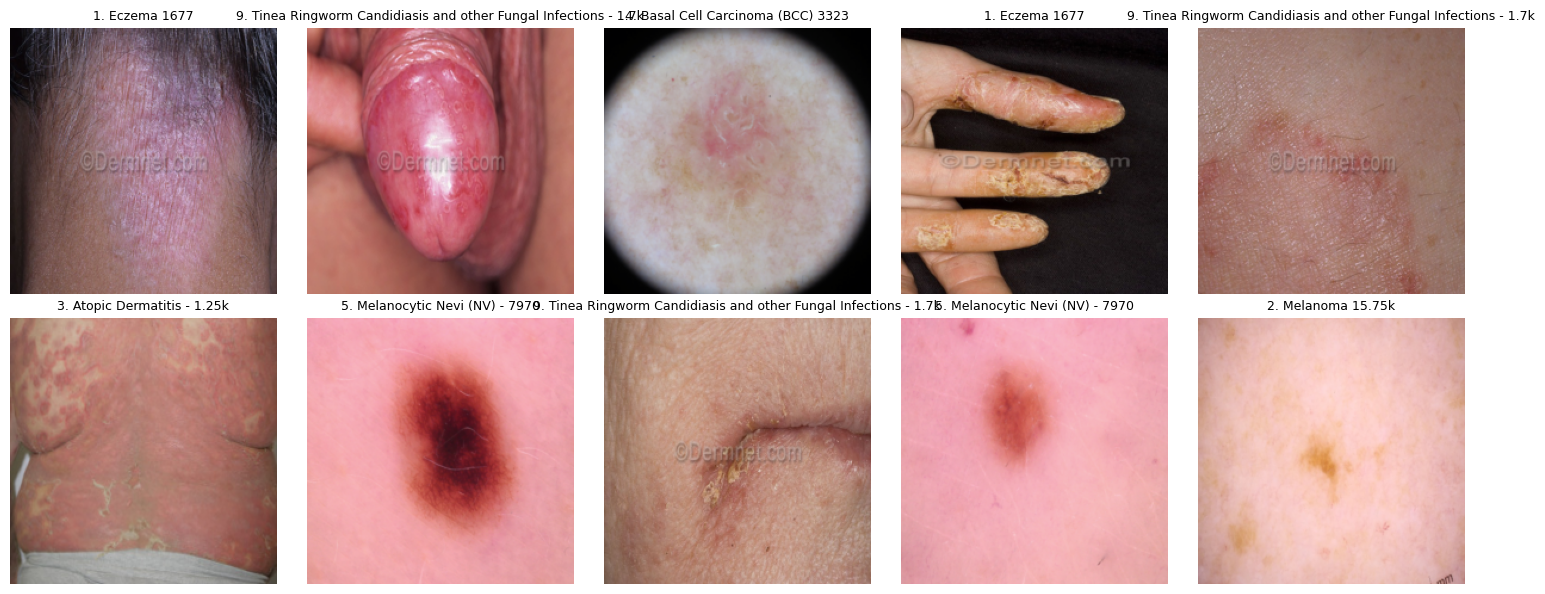

Sample saved.


In [10]:
# Show sample images from each class
fig, axes = plt.subplots(2, min(5, NUM_CLASSES), figsize=(15, 6))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

images, labels = next(iter(train_loader))

for i in range(min(10, len(images))):
    img = images[i].numpy().transpose(1, 2, 0)
    img = (img * std + mean).clip(0, 1)
    axes[i].imshow(img)
    axes[i].set_title(CLASS_NAMES[labels[i]], fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../model/sample_images.png', dpi=100)
plt.show()
print("Sample saved.")

## Step 7: Build Model (EfficientNet-B0 Transfer Learning)

In [11]:
def build_model(num_classes):
    # Load pretrained EfficientNet-B0
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 2 feature blocks for fine-tuning
    for param in model.features[-2:].parameters():
        param.requires_grad = True

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )

    return model

model = build_model(NUM_CLASSES).to(DEVICE)

# Count trainable params
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\User/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:08<00:00, 2.53MB/s]


Total params    : 4,338,054
Trainable params: 1,459,898


## Step 8: Loss, Optimizer & Scheduler

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)

# Cosine annealing — reduces LR smoothly over epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("Loss, Optimizer and Scheduler ready.")

Loss, Optimizer and Scheduler ready.


## Step 9: Training Loop

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Val", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, correct / total

In [14]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

print(f"Starting training for {EPOCHS} epochs on {DEVICE}")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  "
          f"LR: {scheduler.get_last_lr()[0]:.6f}  "
          f"Time: {elapsed:.1f}s")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'val_acc'    : val_acc,
            'num_classes': NUM_CLASSES,
            'class_names': CLASS_NAMES
        }, MODEL_SAVE)
        print(f"  ✅ Best model saved (val_acc: {val_acc:.4f})")

print("-" * 65)
print(f"Training complete. Best Val Accuracy: {best_val_acc:.4f}")

Starting training for 15 epochs on cuda
-----------------------------------------------------------------


Epoch [01/15] Train Loss: 1.1793  Train Acc: 0.5713  Val Loss: 0.8247  Val Acc: 0.6823  LR: 0.000099  Time: 131.4s
  ✅ Best model saved (val_acc: 0.6823)


Epoch [02/15] Train Loss: 0.8404  Train Acc: 0.6763  Val Loss: 0.7191  Val Acc: 0.7289  LR: 0.000096  Time: 86.6s
  ✅ Best model saved (val_acc: 0.7289)


Epoch [03/15] Train Loss: 0.7390  Train Acc: 0.7199  Val Loss: 0.6622  Val Acc: 0.7554  LR: 0.000090  Time: 86.8s
  ✅ Best model saved (val_acc: 0.7554)


Epoch [04/15] Train Loss: 0.6773  Train Acc: 0.7472  Val Loss: 0.6221  Val Acc: 0.7720  LR: 0.000083  Time: 86.9s
  ✅ Best model saved (val_acc: 0.7720)


...

Epoch [11/15] Train Loss: 0.4510  Train Acc: 0.8355  Val Loss: 0.5526  Val Acc: 0.8006  LR: 0.000017  Time: 80.5s
  ✅ Best model saved (val_acc: 0.8006)


Epoch [12/15] Train Loss: 0.4443  Train Acc: 0.8380  Val Loss: 0.5542  Val Acc: 0.8018  LR: 0.000010  Time: 93.9s
  ✅ Best model saved (val_acc: 0.8018)


Epoch [13/15] Train Loss: 0.4324  Train Acc: 0.8450  Val Loss: 0.5481  Val Acc: 0.8041  LR: 0.000004  Time: 92.8s
  ✅ Best model saved (val_acc: 0.8041)


Epoch [14/15] Train Loss: 0.4346  Train Acc: 0.8392  Val Loss: 0.5530  Val Acc: 0.8064  LR: 0.000001  Time: 80.8s
  ✅ Best model saved (val_acc: 0.8064)


Epoch [15/15] Train Loss: 0.4270  Train Acc: 0.8446  Val Loss: 0.5533  Val Acc: 0.8029  LR: 0.000000  Time: 80.5s
-----------------------------------------------------------------
Training complete. Best Val Accuracy: 0.8064


## Step 10: Plot Training Curves

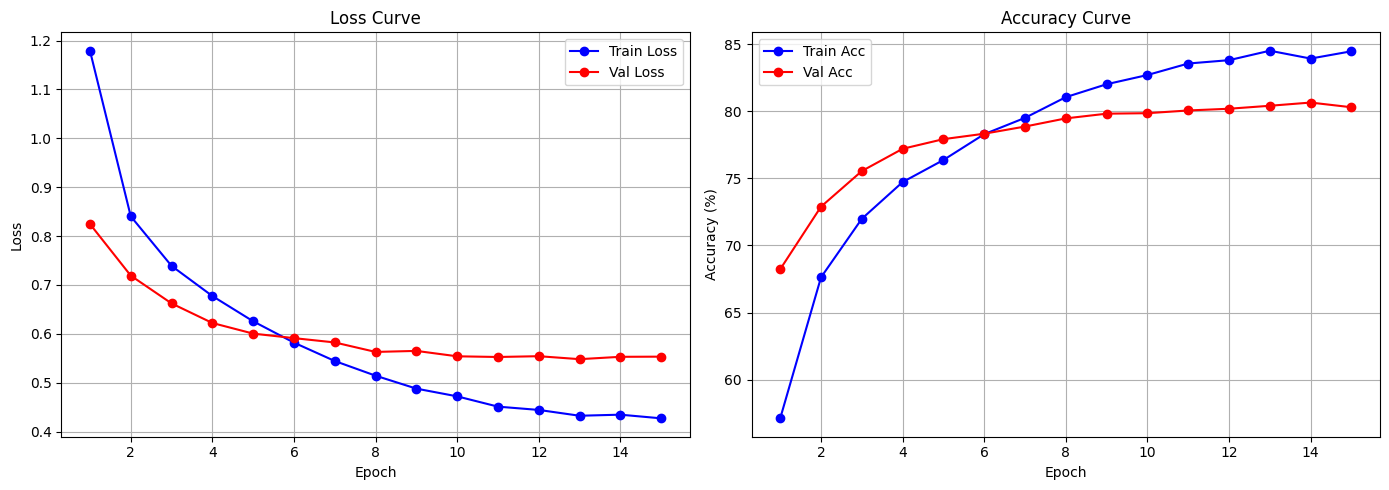

Curves saved to ../model/training_curves.png


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('../model/training_curves.png', dpi=100)
plt.show()
print("Curves saved to ../model/training_curves.png")

## Step 11: Confusion Matrix & Classification Report

In [16]:
# Load best model weights before evaluation
checkpoint = torch.load(MODEL_SAVE, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

C:\Users\User\AppData\Local\Temp\ipykernel_7564\140331456.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_SAVE, map_location=DEVICE)
Evalua


Classification Report:
                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.61      0.61      0.61       323
           10. Warts Molluscum and other Viral Infections - 2103       0.69      0.69      0.69       452
                                              2. Melanoma 15.75k       0.97      0.94      0.96       654
                                    3. Atopic Dermatitis - 1.25k       0.53      0.54      0.53       262
                              4. Basal Cell Carcinoma (BCC) 3323       0.87      0.94      0.90       638
                                 5. Melanocytic Nevi (NV) - 7970       0.93      0.97      0.95      1543
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.83      0.69      0.75       421
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.62      0.52      0.57       417
          8. Seborrhe

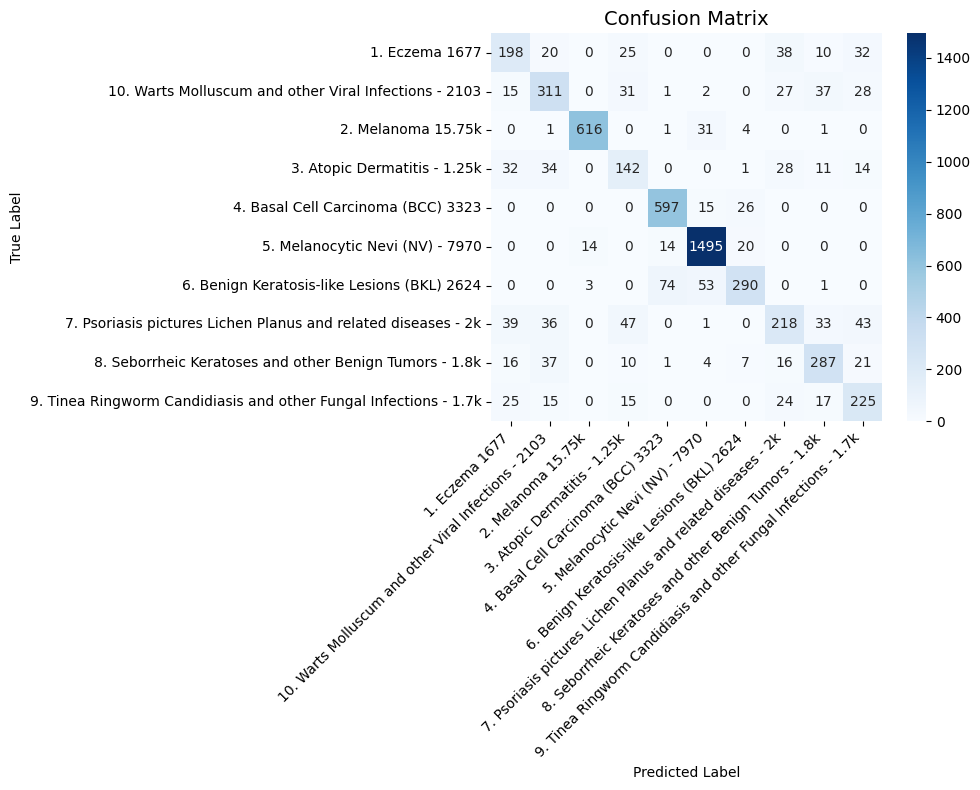

Confusion matrix saved.


In [17]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES - 2)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix', fontsize=14)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../model/confusion_matrix.png', dpi=100)
plt.show()
print("Confusion matrix saved.")

## Step 12: Quick Inference Test

True label: 2. Melanoma 15.75k

Image: C:\Users\User\.cache\kagglehub\datasets\ismailpromus\skin-diseases-image-dataset\versions\1\IMG_CLASSES\2. Melanoma 15.75k\ISIC_7128007.jpg
Top Predictions:
  2. Melanoma 15.75k              99.91%
  5. Melanocytic Nevi (NV) - 7970  0.09%
  6. Benign Keratosis-like Lesions (BKL) 2624  0.00%
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k  0.00%
  4. Basal Cell Carcinoma (BCC) 3323  0.00%


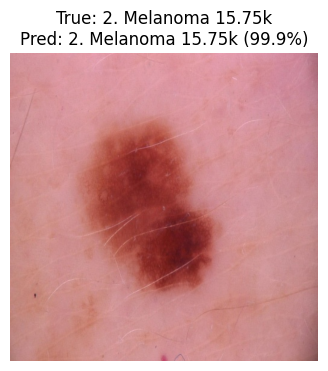

In [18]:
from PIL import Image

def predict_image(image_path, model, class_names, device):
    """Run inference on a single image."""
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
        top5    = torch.topk(probs, k=min(5, len(class_names)))

    print(f"\nImage: {image_path}")
    print("Top Predictions:")
    for i in range(top5.indices.shape[0]):
        idx   = top5.indices[i].item()
        score = top5.values[i].item()
        print(f"  {class_names[idx]:30s}  {score*100:.2f}%")

    best_idx  = top5.indices[0].item()
    best_conf = top5.values[0].item()
    return class_names[best_idx], best_conf


# --- Test on a random validation image ---
import random

# Pick a random sample from validation set
sample_idx   = random.choice(val_dataset.indices)
sample_path  = full_dataset.samples[sample_idx][0]
true_label   = full_dataset.samples[sample_idx][1]

print(f"True label: {CLASS_NAMES[true_label]}")
pred_class, confidence = predict_image(sample_path, model, CLASS_NAMES, DEVICE)

# Show the image
img = Image.open(sample_path)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"True: {CLASS_NAMES[true_label]}\nPred: {pred_class} ({confidence*100:.1f}%)")
plt.axis('off')
plt.show()

## ✅ Done! Summary

In [ ]:
print("=" * 50)
print("TRAINING SUMMARY")
print("=" * 50)
print(f"Model        : EfficientNet-B0 (Transfer Learning)")
print(f"Classes      : {NUM_CLASSES}")
print(f"Best Val Acc : {best_val_acc*100:.2f}%")
print(f"Model saved  : {MODEL_SAVE}")
print(f"Labels saved : {LABELS_SAVE}")
print("=" * 50)
print("Files in ./model/:")
for f in os.listdir('./model'):
    size = os.path.getsize(f'./model/{f}') / 1e6
    print(f"  {f:40s}  {size:.2f} MB")

TRAINING SUMMARY
Model        : EfficientNet-B0 (Transfer Learning)
Classes      : 10
Best Val Acc : 80.64%
Model saved  : ../model/efficientnet_skin.pth
Labels saved : ../model/class_labels.json
Files in ../model/:
  class_labels.json                         0.00 MB
  confusion_matrix.png                      0.13 MB
  efficientnet_skin.pth                     29.35 MB
  sample_images.png                         1.08 MB
  training_curves.png                       0.05 MB
